In [14]:
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
from scipy.stats import f_oneway

In [15]:
df = pd.read_csv("../data/London/enriched/listing_master.csv")

## 5.1 Hypothesis Testing 

In [16]:
# Cohen's d Function

def cohens_d(group1, group2):

    n1 = len(group1)
    n2 = len(group2)

    pooled_std = np.sqrt(
        (
            ((n1 - 1) * np.var(group1, ddof=1))
            +
            ((n2 - 1) * np.var(group2, ddof=1))
        )
        /
        (n1 + n2 - 2)
    )

    d = (
        np.mean(group1)
        -
        np.mean(group2)
    ) / pooled_std

    return d

In [17]:
# H1 - Entire Home vs Private Room Prices

entire_home = (
    df.loc[
        df["room_type"] == "Entire home/apt",
        "price_clean"
    ]
    .dropna()
)

private_room = (
    df.loc[
        df["room_type"] == "Private room",
        "price_clean"
    ]
    .dropna()
)

In [18]:
t_stat, p_value = ttest_ind(
    entire_home,
    private_room,
    equal_var=False
)

effect_size = cohens_d(
    entire_home,
    private_room
)

h1_t = t_stat
h1_p = p_value
h1_d = effect_size

print("H1 Results")
print("t-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 4))
print("Cohen's d:", round(effect_size, 4))

H1 Results
t-statistic: 5.7951
p-value: 0.0
Cohen's d: 0.0355


In [19]:
# H2 - Superhost vs Non-Superhost Ratings

superhost = (
    df.loc[
        df["host_is_superhost"] == "t",
        "review_scores_rating"
    ]
    .dropna()
)

non_superhost = (
    df.loc[
        df["host_is_superhost"] == "f",
        "review_scores_rating"
    ]
    .dropna()
)

In [20]:
t_stat, p_value = ttest_ind(
    superhost,
    non_superhost,
    equal_var=False
)

effect_size = cohens_d(
    superhost,
    non_superhost
)

h2_t = t_stat
h2_p = p_value
h2_d = effect_size

print("H2 Results")
print("t-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 4))
print("Cohen's d:", round(effect_size, 4))

H2 Results
t-statistic: 76.0379
p-value: 0.0
Cohen's d: 0.444


In [21]:
# H3 - More Than 10 Reviews vs 10 or Less

high_reviews = (
    df.loc[
        df["number_of_reviews"] > 10,
        "price_clean"
    ]
    .dropna()
)

low_reviews = (
    df.loc[
        df["number_of_reviews"] <= 10,
        "price_clean"
    ]
    .dropna()
)

In [22]:
t_stat, p_value = ttest_ind(
    high_reviews,
    low_reviews,
    equal_var=False
)

effect_size = cohens_d(
    high_reviews,
    low_reviews
)

h3_t = t_stat
h3_p = p_value
h3_d = effect_size

print("H3 Results")
print("t-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 4))
print("Cohen's d:", round(effect_size, 4))

H3 Results
t-statistic: -2.675
p-value: 0.0075
Cohen's d: -0.0188


In [23]:
# H4 - Neighbourhood Price Differences

top_neighbourhoods = (
    df["neighbourhood_cleansed"]
    .value_counts()
    .head(10)
    .index
)

In [24]:
anova_groups = []

for neighbourhood in top_neighbourhoods:

    prices = (
        df.loc[
            df["neighbourhood_cleansed"] == neighbourhood,
            "price_clean"
        ]
        .dropna()
    )

    anova_groups.append(prices)

In [29]:
f_stat, p_value = f_oneway(
    *anova_groups
)

h4_f = f_stat
h4_p = p_value

print("H4 Results")
print("F-statistic:", round(h4_f, 4))
print("p-value:", round(h4_p, 4))

H4 Results
F-statistic: 1.0939
p-value: 0.3632


In [31]:
h4_d = "NaN";

results = pd.DataFrame({
    "Hypothesis": [
        "H1",
        "H2",
        "H3",
        "H4"
    ],
    "Test": [
        "T-Test",
        "T-Test",
        "T-Test",
        "ANOVA"
    ],
    "Statistic": [
        h1_t,
        h2_t,
        h3_t,
        f_stat
    ],
    "P_Value": [
        h1_p,
        h2_p,
        h3_p,
        p_value
    ],
    "Effect_Size": [
        h1_d,
        h2_d,
        h3_d,
        h4_d
        
    ]
})

In [32]:
results

,Hypothesis,Test,Statistic,P_Value,Effect_Size
0,H1,T-Test,5.795141,6.866495e-09,0.035453
1,H2,T-Test,76.037860,0.000000e+00,0.443974
2,H3,T-Test,-2.675007,7.475927e-03,-0.018772
3,H4,ANOVA,1.093901,3.631986e-01,NaN


## 5.2 Confidence Intervals & Effect Sizes 

In [33]:
from scipy.stats import sem
from scipy.stats import t

In [34]:
def confidence_interval(series, confidence=0.95):

    series = series.dropna()

    n = len(series)
    mean = series.mean()

    margin = (
        sem(series)
        * t.ppf(
            (1 + confidence) / 2,
            n - 1
        )
    )

    return pd.Series({
        "mean_price": mean,
        "ci_lower": mean - margin,
        "ci_upper": mean + margin
    })

In [35]:
# 95% Confindence Interval by Room Type

roomtype_ci = (
    df.groupby("room_type")
    ["price_clean"]
    .apply(confidence_interval)
    .unstack()
)

roomtype_ci.round(2)


,mean_price,ci_lower,ci_upper
room_type,,,
Entire home/apt,279.35,228.78,329.91
Hotel room,657.83,364.31,951.36
Private room,121.71,104.81,138.62
Shared room,96.91,62.06,131.76


In [36]:
# top 10 neighbourhoods

top_neighbourhoods = (
    df["neighbourhood_cleansed"]
    .value_counts()
    .head(10)
    .index
)

In [37]:
neighbourhood_ci = (
    df[
        df["neighbourhood_cleansed"]
        .isin(top_neighbourhoods)
    ]
    .groupby("neighbourhood_cleansed")
    ["price_clean"]
    .apply(confidence_interval)
    .unstack()
)

neighbourhood_ci.round(2)

,mean_price,ci_lower,ci_upper
neighbourhood_cleansed,,,
Camden,216.51,204.26,228.77
Hackney,161.13,152.21,170.04
Hammersmith And Fulham,199.19,188.14,210.24
Islington,217.55,163.33,271.76
Kensington And Chelsea,336.07,310.61,361.54
Lambeth,345.71,238.12,453.30
Southwark,174.28,160.05,188.50
Tower Hamlets,430.91,-66.81,928.63
Wandsworth,198.43,184.18,212.68


In [38]:
import matplotlib.pyplot as plt

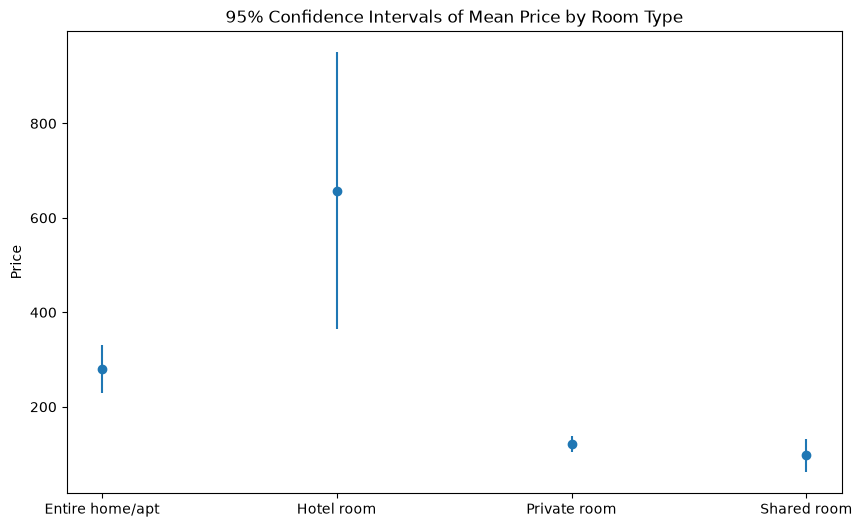

In [39]:
plt.figure(figsize=(10,6))

plt.errorbar(
    roomtype_ci.index,
    roomtype_ci["mean_price"],
    yerr=[
        roomtype_ci["mean_price"] - roomtype_ci["ci_lower"],
        roomtype_ci["ci_upper"] - roomtype_ci["mean_price"]
    ],
    fmt="o"
)

plt.title(
    "95% Confidence Intervals of Mean Price by Room Type"
)

plt.ylabel("Price")

plt.show()

## 5.3  Correlation & Driver Analysis 

# Correlation Heatmap

In [40]:
corr_features = [
    "price_clean",
    "accommodates",
    "bedrooms",
    "beds",
    "review_scores_rating",
    "number_of_reviews",
    "reviews_per_month",
    "host_tenure_years",
    "occupancy_rate",
    "estimated_revenue"
]

In [41]:
corr_matrix = (
    df[corr_features]
    .corr(numeric_only=True)
)

corr_matrix.round(2)

,price_clean,accommodates,bedrooms,beds,review_scores_rating,number_of_reviews,reviews_per_month,host_tenure_years,occupancy_rate,estimated_revenue
price_clean,1.00,0.02,0.02,0.02,-0.01,-0.01,-0.02,-0.01,-0.01,0.17
accommodates,0.02,1.00,0.74,0.68,-0.04,-0.05,0.03,-0.05,-0.11,0.11
bedrooms,0.02,0.74,1.00,0.63,0.03,-0.10,-0.09,0.05,0.04,0.11
beds,0.02,0.68,0.63,1.00,-0.02,-0.05,-0.02,-0.01,-0.02,0.09
review_scores_rating,-0.01,-0.04,0.03,-0.02,1.00,0.07,0.05,0.19,0.12,0.02
number_of_reviews,-0.01,-0.05,-0.10,-0.05,0.07,1.00,0.51,0.13,-0.05,-0.02
reviews_per_month,-0.02,0.03,-0.09,-0.02,0.05,0.51,1.00,-0.20,-0.20,-0.03
host_tenure_years,-0.01,-0.05,0.05,-0.01,0.19,0.13,-0.20,1.00,0.28,0.02
occupancy_rate,-0.01,-0.11,0.04,-0.02,0.12,-0.05,-0.20,0.28,1.00,0.21
estimated_revenue,0.17,0.11,0.11,0.09,0.02,-0.02,-0.03,0.02,0.21,1.00


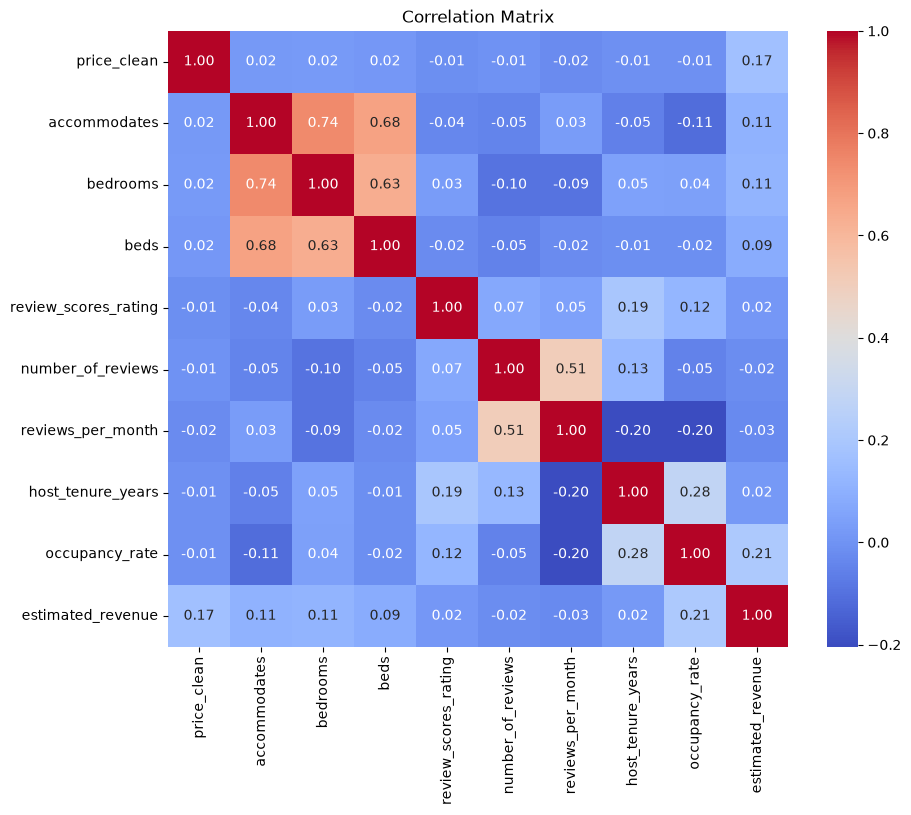

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix"
)

plt.show()

# OLS Regression

In [44]:
import statsmodels.api as sm

In [45]:
regression_df = df[
    [
        "price_clean",
        "accommodates",
        "bedrooms",
        "beds",
        "review_scores_rating",
        "host_tenure_years"
    ]
].dropna()

In [46]:
X = regression_df[
    [
        "accommodates",
        "bedrooms",
        "beds",
        "review_scores_rating",
        "host_tenure_years"
    ]
]

y = regression_df["price_clean"]

X = sm.add_constant(X)

In [47]:
model = sm.OLS(
    y,
    X
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            price_clean   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     111.3
Date:                Tue, 23 Jun 2026   Prob (F-statistic):          2.31e-117
Time:                        20:57:45   Log-Likelihood:            -3.9203e+05
No. Observations:               47971   AIC:                         7.841e+05
Df Residuals:                   47965   BIC:                         7.841e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  130.7848 

# VIF Analysis

In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [49]:
vif_df = pd.DataFrame()

vif_df["Feature"] = X.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif_df

,Feature,VIF
0,const,88.001653
1,accommodates,3.970985
2,bedrooms,2.827663
3,beds,3.315290
4,review_scores_rating,1.038532
5,host_tenure_years,1.041101


# LOWESS Plot

In [51]:
import seaborn as sns

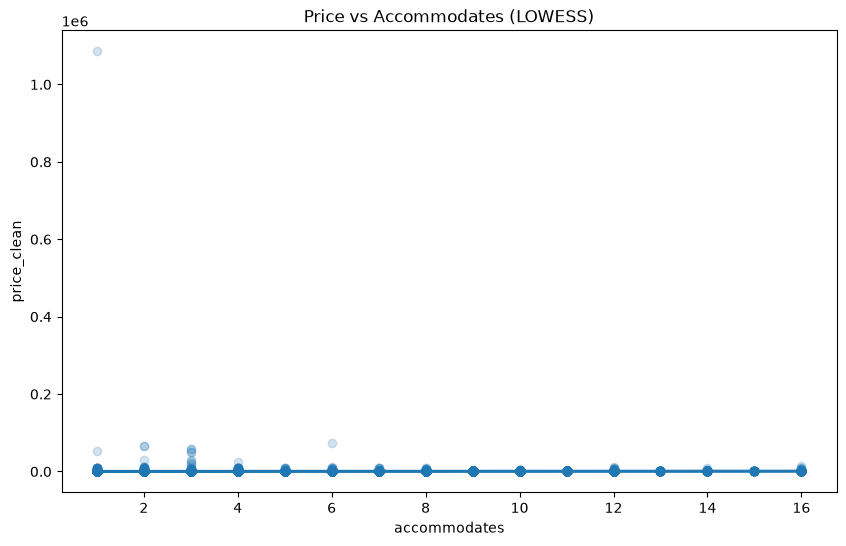

In [54]:
# Price vs Accommodates

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="accommodates",
    y="price_clean",
    lowess=False,
    scatter_kws={"alpha":0.2}
)

plt.title(
    "Price vs Accommodates (LOWESS)"
)

plt.show()